In [1]:
import pandas as pd
import numpy as np
import scipy
import seaborn as sns
import glob
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings
import scanpy as sc
import sklearn
from adjustText import adjust_text
import anndata as ad

warnings.filterwarnings("ignore")

In [2]:
import module_02_doublets_analysis as m02

In [3]:
sc.settings.figdir = '../figures/revision/FS1/'

In [4]:
adata_doublets=sc.read_h5ad('../data/PICseq/final_data/adata_doublets_final.h5ad')
adata_doublets_imp=sc.read_h5ad('../data/PICseq/final_data/adata_doublets_final_imp.h5ad')
adata_singlets=sc.read_h5ad('../data/PICseq/final_data/adata_singlets_final.h5ad')
adata_singlets_imp=sc.read_h5ad('../data/PICseq/final_data/adata_singlets_final_imp.h5ad')

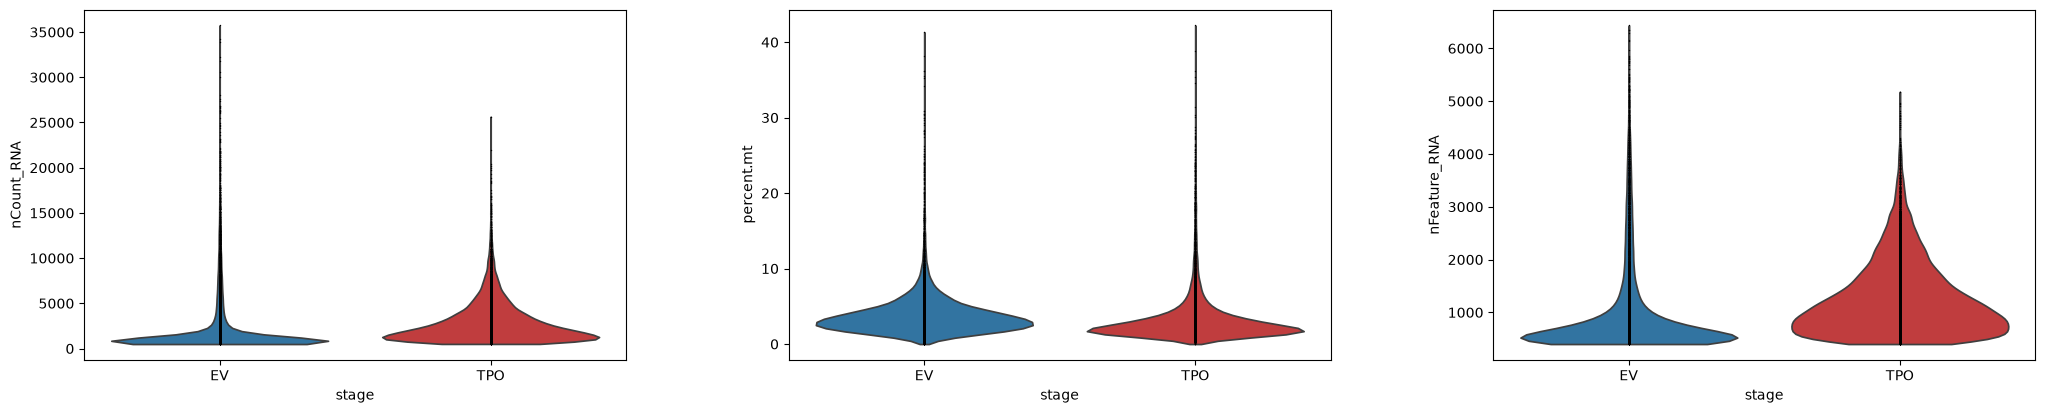

In [5]:
sc.pl.violin(adata_doublets, ['nCount_RNA', 'percent.mt','nFeature_RNA'], groupby = 'stage', palette={"EV": "tab:blue", "TPO": "tab:red"}, jitter=False,
            save='_FS1H_doublets.pdf')

In [6]:
adata_doublets.obs.nCount_RNA.mean()

np.float64(2388.509978567651)

In [7]:
adata_doublets.obs.nCount_RNA.median()

np.float64(1314.0)

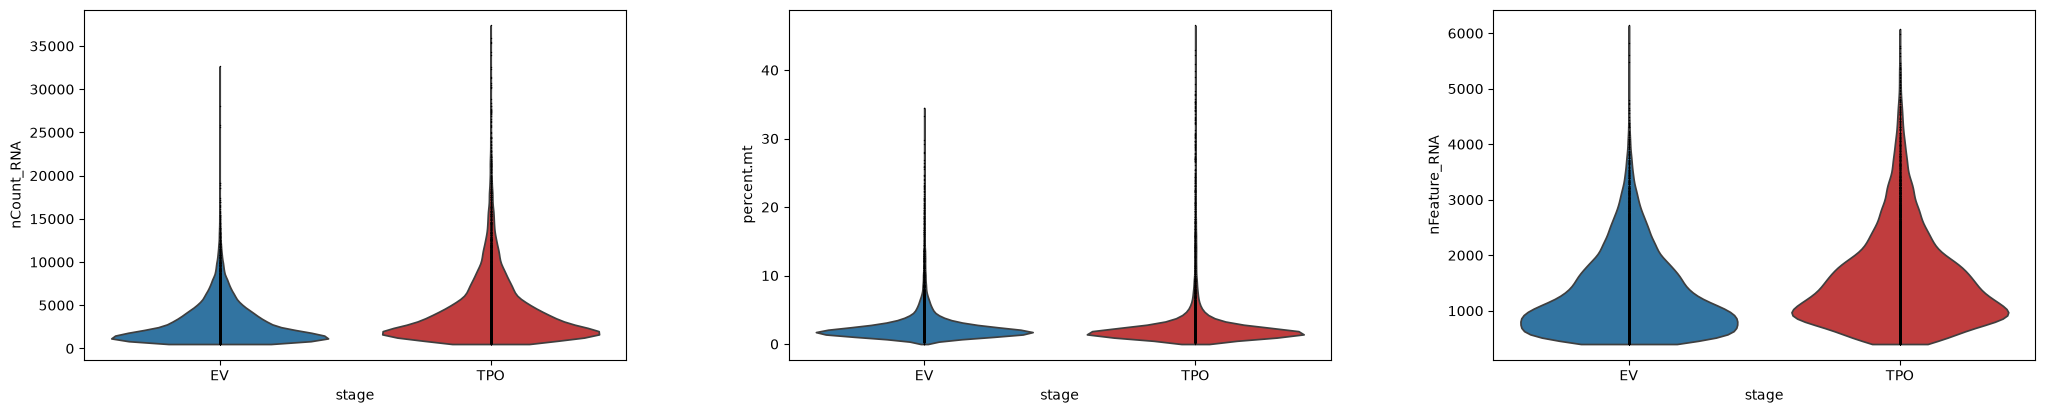

In [8]:
sc.pl.violin(adata_singlets, ['nCount_RNA', 'percent.mt','nFeature_RNA'], groupby = 'stage', palette={"EV": "tab:blue", "TPO": "tab:red"}, jitter=False,
            save='_FS1H_singlets.pdf')

In [9]:
adata_singlets.obs.nCount_RNA.mean()

np.float64(3635.2146343267027)

In [10]:
adata_singlets.obs.nCount_RNA.median()

np.float64(2575.0)

In [11]:
CTprops_2CTs=pd.read_csv('../res_data/revision/deconvolution/PICseq_doublets_CTprops_BP_annotation_2CTs_noMSCs_Xist_newNames.csv', index_col=0)

In [12]:
###### UMAPs

In [13]:
sc.settings.figdir = '../figures/revision/F1/'

findfont: Failed to find font weight 3, now using 200.


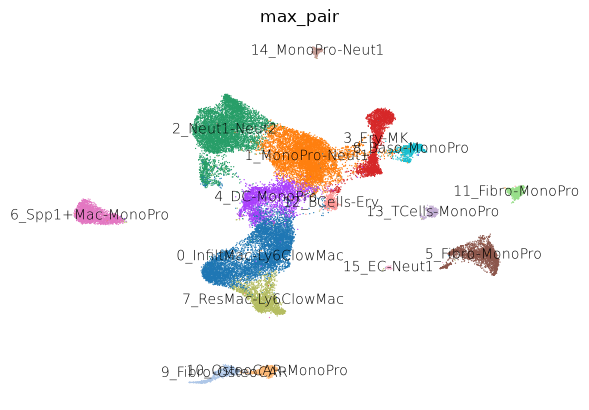

In [14]:
sc.pl.umap(adata_doublets, color='max_pair', legend_loc="on data", frameon=False, save='_F1F.pdf', legend_fontweight=3)

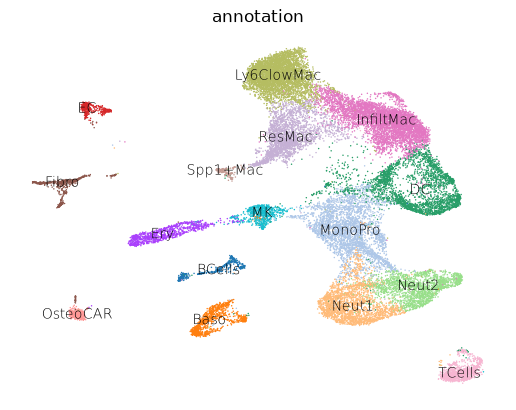

In [15]:
sc.pl.umap(adata_singlets, color='annotation', legend_loc="on data", frameon=False, save='_F1C.pdf', legend_fontweight=3)

In [16]:
tmp=m02.get_CTprops_barplot_df(CTprobs=CTprops_2CTs, clusts=adata_doublets.obs.max_pair)
tmp.head()

clusters,0_InfiltMac-Ly6ClowMac,1_MonoPro-Neut1,2_Neut1-Neut2,3_Ery-MK,4_DC-MonoPro,5_Fibro-MonoPro,6_Spp1+Mac-MonoPro,7_ResMac-Ly6ClowMac,8_Baso-MonoPro,9_Fibro-OsteoCAR,10_OsteoCAR-MonoPro,11_Fibro-MonoPro,12_BCells-Ery,13_TCells-MonoPro,14_MonoPro-Neut1,15_EC-Neut1
DC,0.000000,0.000000,0.000000,0.0,0.627031,0.000000,0.00000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.00000,0.000000,0.0
InfiltMac,0.423086,0.000000,0.000000,0.0,0.000000,0.000000,0.00000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.00000,0.000000,0.0
Fibro,0.000000,0.000000,0.000000,0.0,0.000000,0.460648,0.00000,0.0,0.000000,0.263295,0.000000,0.466784,0.0,0.00000,0.000000,0.0
MonoPro,0.000000,0.669584,0.000000,0.0,0.152504,0.155135,0.10727,0.0,0.074643,0.000000,0.105668,0.172032,0.0,0.05904,0.216378,0.0
Neut2,0.000000,0.000000,0.280605,0.0,0.000000,0.000000,0.00000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.00000,0.000000,0.0


In [17]:
cell_colors=['#8DD3C7', '#FB8072', '#3DA397', '#A65628', '#FDB462',
             '#80B1D3', '#984EA3', '#F781BF', '#CCEBC5', '#E41A1C',
             '#00BE67', '#AAD6FF', '#862635', '#4DAF4A', '#C77CFF', '#377EB8', 'lightgray']

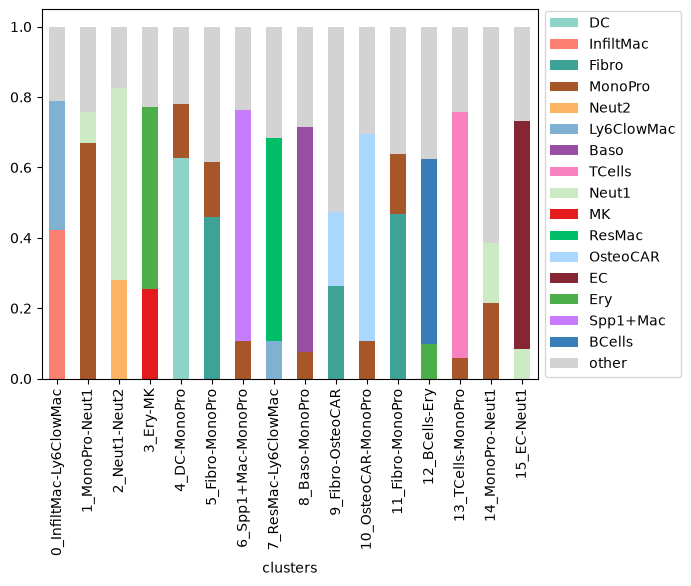

In [18]:
plt.style.use('default')
tmp.T.plot.bar(stacked=True, color=cell_colors)
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.savefig('../figures/revision/FS1/FS1L.pdf',  bbox_inches="tight")
plt.show()

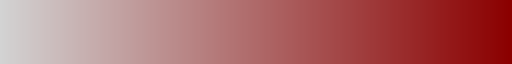

In [19]:
newcmp=mcolors.LinearSegmentedColormap.from_list("GreyRed",['lightgrey', "darkred"])
newcmp

In [20]:
### Gli1_Pf4 double positive cells

In [21]:
sc.settings.figdir = '../figures/revision/FS1/'

In [22]:
thr=0.001 ## Gli1 expression is low

In [23]:
adata_doublets_imp.obs['Gli1_Pf4_pos']='other'
adata_doublets_imp.obs['Gli1_Pf4_pos'][(adata_doublets_imp.to_df()['Gli1']>thr)&(adata_doublets_imp.to_df()['Pf4']>thr)]='double positive'
adata_doublets_imp.obs['Gli1_Pf4_pos']=adata_doublets_imp.obs['Gli1_Pf4_pos'].astype('category')
adata_doublets_imp.obs['Gli1_Pf4_pos']=adata_doublets_imp.obs['Gli1_Pf4_pos'].cat.reorder_categories(['other', 'double positive'])
adata_doublets_imp.uns['Gli1_Pf4_pos_colors']=['lightgrey', 'darkred']

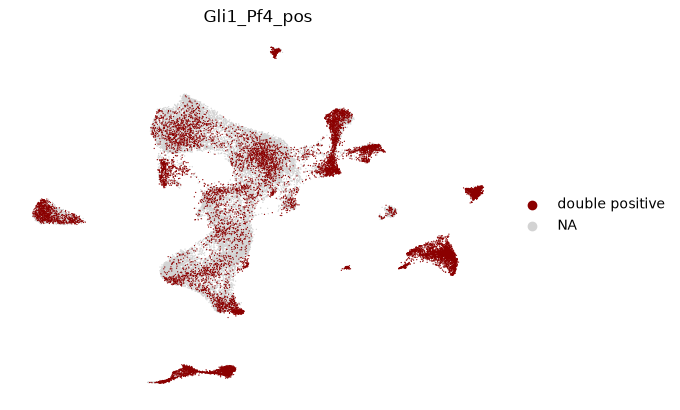

In [24]:
sc.pl.umap(adata_doublets_imp, color=['Gli1_Pf4_pos'], frameon=False, save='_FS1O.pdf', legend_fontweight=3, cmap=newcmp, groups=['double positive'])

In [25]:
adata_singlets_imp.obs['Gli1_Pf4_pos']=0
adata_singlets_imp.obs['Gli1_Pf4_pos'][(adata_singlets_imp.to_df()['Gli1']>thr)&(adata_singlets_imp.to_df()['Pf4']>thr)]=1

In [26]:
sing_data = {'Gli1_Pf4_pos': list(adata_singlets_imp.obs['Gli1_Pf4_pos'])}
doub_data = {'Gli1_Pf4_pos': list(adata_doublets_imp.obs['Gli1_Pf4_pos'])}

df = pd.DataFrame([[label, val, 'singlets'] for label, values in sing_data.items() for val in values]
                  + [[label, val, 'doublets'] for label, values in doub_data.items() for val in values],
                  columns=['label', 'value', 'source'])

In [27]:
df.label[(df.value==0)|(df.value=='other')]='Gli1_Pf4_neg'

<Axes: xlabel='source'>

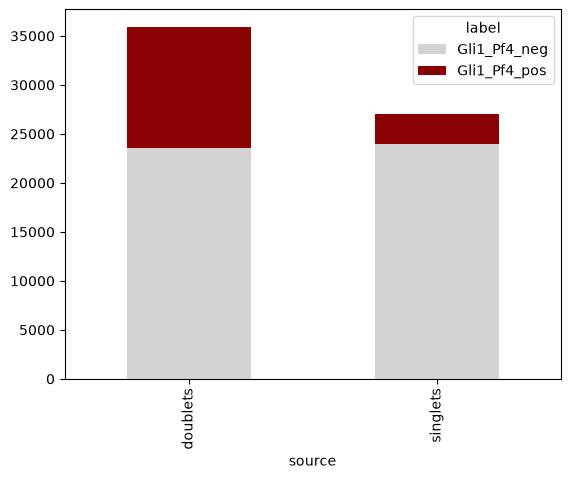

In [28]:
Gli1_Pf4_in_cells=df.groupby(['source', 'label']).size().unstack()
ccols=['lightgrey', "darkred"]
Gli1_Pf4_in_cells.plot.bar(stacked=True, color=ccols)

In [29]:
Gli1_Pf4_in_cells

label,Gli1_Pf4_neg,Gli1_Pf4_pos
source,,
doublets,23599,12328
singlets,23962,3084


In [30]:
Gli1_Pf4_in_cells.sum(axis=1)

source
doublets    35927
singlets    27046
dtype: int64

In [31]:
## Gli or Pf4 + singlets
thr2=0.001
adata_singlets_imp.obs['Gli1_or_Pf4']='None'
adata_singlets_imp.obs['Gli1_or_Pf4'][(adata_singlets_imp.to_df()['Pf4']>thr2)]='Pf4'
adata_singlets_imp.obs['Gli1_or_Pf4'][(adata_singlets_imp.to_df()['Gli1']>thr2)]='Gli1'
adata_singlets_imp.obs['Gli1_or_Pf4'][(adata_singlets_imp.to_df()['Gli1']>thr2)&(adata_singlets_imp.to_df()['Pf4']>thr2)]='both'


In [32]:
adata_singlets_imp.obs['Gli1_or_Pf4'].value_counts()

Gli1_or_Pf4
Pf4     17959
None     5204
both     3084
Gli1      799
Name: count, dtype: int64

In [33]:
adata_singlets_imp[adata_singlets_imp.obs.stage=='EV'].obs['Gli1_or_Pf4'].value_counts()

Gli1_or_Pf4
Pf4     10497
None     2381
both     1289
Gli1      506
Name: count, dtype: int64

In [34]:
adata_singlets_imp[adata_singlets_imp.obs.stage=='TPO'].obs['Gli1_or_Pf4'].value_counts()

Gli1_or_Pf4
Pf4     7462
None    2823
both    1795
Gli1     293
Name: count, dtype: int64

In [35]:
adata_singlets_imp.uns['Gli1_or_Pf4_colors']=['red', 'blue', 'grey', 'purple']

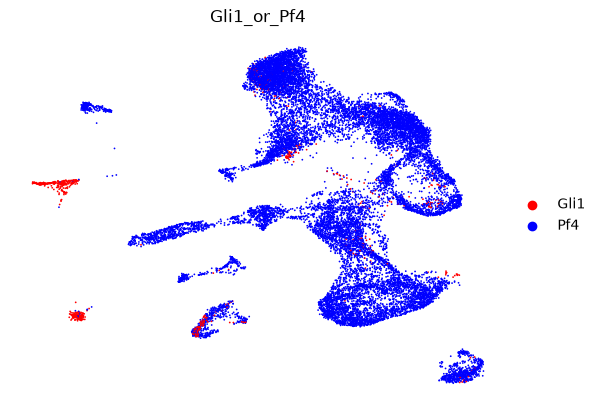

In [36]:
sc.pl.umap(adata_singlets_imp[(adata_singlets_imp.obs['Gli1_or_Pf4']!='both')&(adata_singlets_imp.obs['Gli1_or_Pf4']!='None')], color='Gli1_or_Pf4', frameon=False, legend_fontweight=3, save='_FS1N.pdf')

In [37]:
clist=['red', 'blue']

In [38]:
sns.set_theme(
    style="white",
    rc={
        "axes.spines.top": True,
        "axes.spines.right": True,
        "axes.spines.left": True,
        "axes.spines.bottom": True,
    },)

<Axes: xlabel='annotation'>

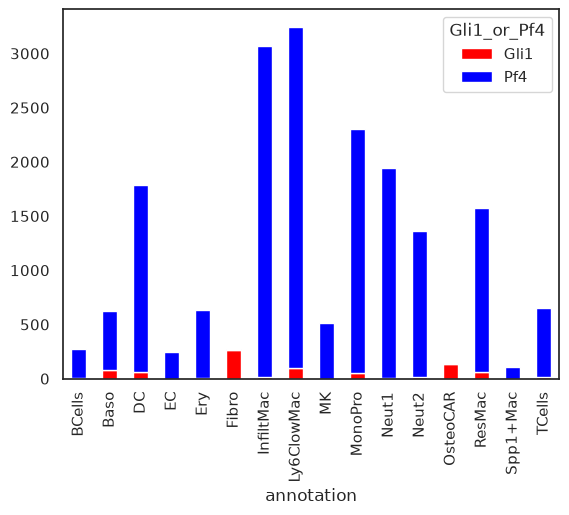

In [39]:
clusts_in_smpls=adata_singlets_imp[(adata_singlets_imp.obs['Gli1_or_Pf4']!='both')&(adata_singlets_imp.obs['Gli1_or_Pf4']!='None')].obs.groupby(['annotation', 'Gli1_or_Pf4']).size().unstack()
clust_cols=pd.Series(clist, index=clusts_in_smpls.columns)
clusts_in_smpls.plot.bar(stacked=True, color=clust_cols)

In [40]:
clusts_in_smpls.T

annotation,BCells,Baso,DC,EC,Ery,Fibro,InfiltMac,Ly6ClowMac,MK,MonoPro,Neut1,Neut2,OsteoCAR,ResMac,Spp1+Mac,TCells
Gli1_or_Pf4,,,,,,,,,,,,,,,,
Gli1,3,80,63,0,3,262,12,95,0,52,4,15,138,60,0,12
Pf4,271,545,1727,246,632,8,3053,3152,515,2247,1937,1348,10,1518,110,640


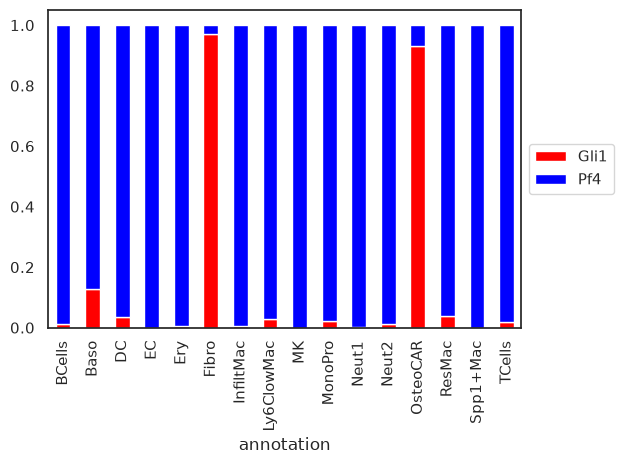

In [41]:
clusts_in_smpls_norm=clusts_in_smpls.T/clusts_in_smpls.T.sum()
clusts_in_smpls_norm.T.plot.bar(stacked=True, color=clust_cols)
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.tight_layout()
plt.savefig('../figures/revision/FS1/FS1M.pdf')

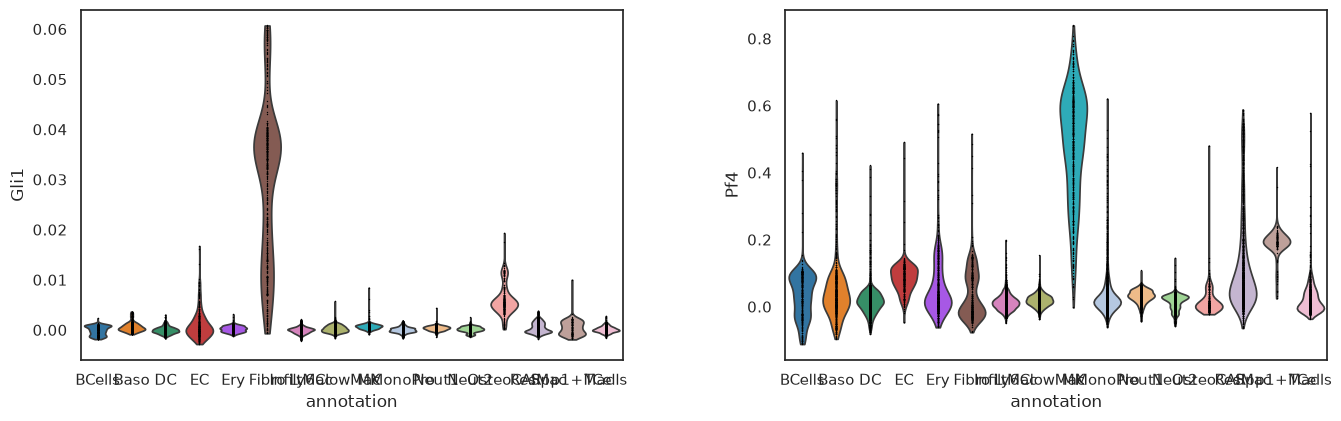

In [42]:
############ Per cell type?
sc.pl.violin(adata_singlets_imp, ['Gli1', 'Pf4'], groupby = 'annotation', jitter=False)

In [43]:
##### Macrophages dot plot

In [44]:
sc.settings.figdir = '../figures/revision/FS2/'

In [45]:
mks_fig2c_LAM={'Antigen_Presentation':['H2-Ab1', 'Cd74', 'Ciita', 'Irf4'], 
           'Complement_Activation':['C3', 'C1qa', 'C1qb', 'C1qc'],
           'Phagocytosis':['Mmp13', 'Cd36', 'Anxa1', 'Gpnmb', 'Ctsd', 'Apoe'],
           'Cell_cycle':['Top2a', 'Mcm2', 'Mki67', 'Tuba1b'],
           'LAM':['Csf1r', 'Lpl', 'Cd9', 'Trap1', 'Trem2', 'Spp1', 'Fabp5']}

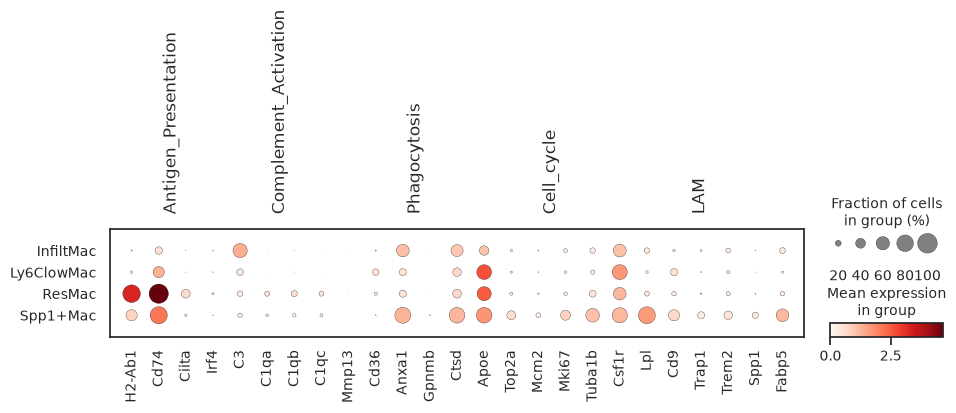

In [46]:
sc.pl.dotplot(adata_singlets[[i in ['Spp1+Mac', 'InfiltMac', 'Ly6ClowMac', 'ResMac'] for i in adata_singlets.obs.annotation]], mks_fig2c_LAM, groupby="annotation", save='_FS2C.pdf')

In [47]:
######## Violin plots data

In [48]:
for ge in ['Spp1', 'Thpo', 'Mpl', 'Il1b', 'S100a9', 'Adipoq', 'Itgav', 'Pf4']:
    tab=m02.getViolinData(adata=adata_singlets, adata_imp=adata_singlets_imp, g=ge, annot_col='annotation', EXP_stage='TPO', WT_stage='WT', savename='../res_data/revision/violin/'+ge+'_sing_violinData_imp_f')

In [49]:
for ge in ['Spp1', 'Thpo', 'Mpl', 'Il1b', 'S100a9', 'Adipoq', 'Itgav', 'Pf4']:
    tab=m02.getViolinData(adata=adata_doublets, adata_imp=adata_doublets_imp, g=ge, annot_col='max_pair', EXP_stage='TPO', WT_stage='WT', savename='../res_data/revision/violin/'+ge+'_doub_violinData_imp_f')

In [50]:
####### Volcano plots

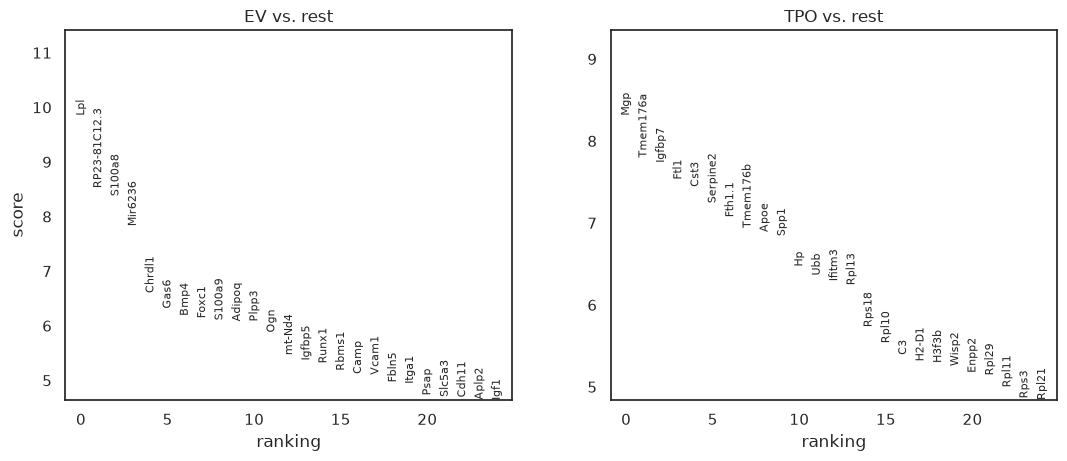

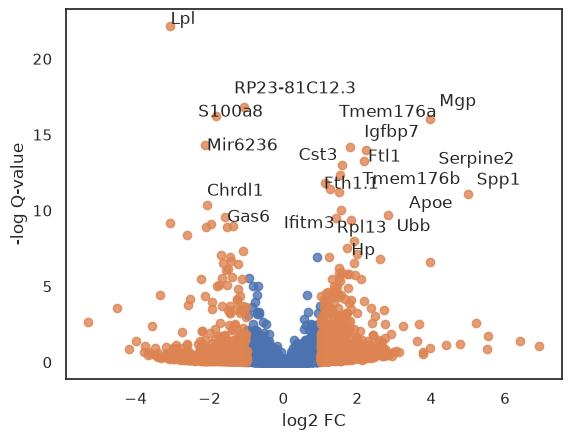

In [51]:
t=m02.doubletsDEA_niche(adata_singlets,  niche_col='annotation', niche_name='OsteoCAR', condition_col='stage', disease_cond_name='TPO', logFC=1)
t.to_csv('../res_data/revision/volcano/singletsDEA_'+'OsteoCAR'+'.csv')

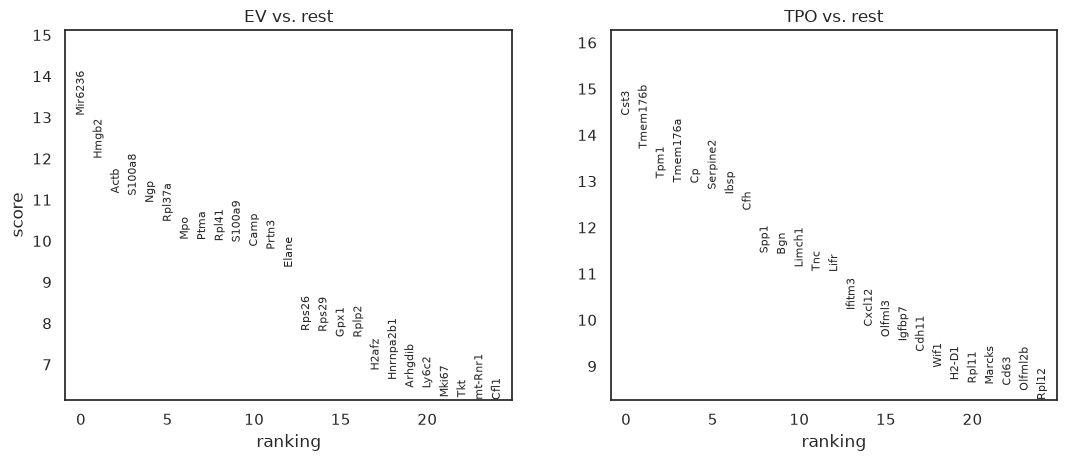

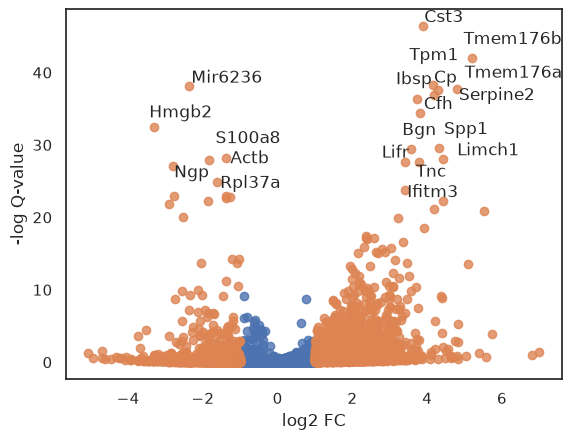

In [52]:
t=m02.doubletsDEA_niche(adata_doublets,  niche_col='harmony_inte_clusters', niche_name='9', condition_col='stage', disease_cond_name='TPO', logFC=1)
t.to_csv('../res_data/revision/volcano/doubletsDEA_dc'+'9'+'.csv')